<a href="https://colab.research.google.com/github/karanmailme1/karanmailme1/blob/main/agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agent

In this notebook, **we're going to build a simple agent using using LangGraph**.

This notebook is part of the <a href="https://www.hf.co/learn/agents-course">Hugging Face Agents Course</a>, a free course from beginner to expert, where you learn to build Agents.

![Agents course share](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/communication/share.png)

As seen in the Unit 1, an agent needs 3 steps as introduced in the ReAct architecture :
[ReAct](https://react-lm.github.io/), a general agent architecture.

* `act` - let the model call specific tools
* `observe` - pass the tool output back to the model
* `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


![Agent](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit2/LangGraph/Agent.png)

In [1]:
%pip install -q -U langchain_openai langchain_core langgraph
!pip install --upgrade --quiet  langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 

In [2]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAI

# Please setp your own key.
# os.environ["OPENAI_API_KEY"] = "sk-xxxxxx"

from google.colab import userdata
GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    api_key=GEMINI_API_KEY,
    max_tokens=8096,
)

In [3]:
import base64
from langchain_core.messages import HumanMessage
#from langchain_openai import ChatOpenAI

vision_llm = model #ChatOpenAI(model="gpt-4o")


def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
    """
    all_text = ""
    try:

        # Read image and encode as base64
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)

        # Append extracted text
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        # You can choose whether to raise or just return an empty string / error message
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""


llm = model #ChatOpenAI(model="gpt-4o")


def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b


tools = [
    divide,
    extract_text
]
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

Let's create our LLM and prompt it with the overall desired agent behavior.

In [4]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The input document
    input_file: Optional[str]  # Contains file path, type (PNG)
    messages: Annotated[list[AnyMessage], add_messages]

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.utils.function_calling import convert_to_openai_tool


def assistant(state: AgentState):
    # System message
    textual_description_of_tool = """
extract_text(img_path: str) -> str:
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
divide(a: int, b: int) -> float:
    Divide a and b
"""
    image = state["input_file"]
    sys_msg = SystemMessage(content=f"You are an helpful agent that can analyse some images and run some computatio without provided tools :\n{textual_description_of_tool} \n You have access to some otpional images. Currently the loaded images is : {image}")

    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])], "input_file": state["input_file"]}

We define a `tools` node with our list of tools.

The `assistant` node is just our model with bound tools.

We create a graph with `assistant` and `tools` nodes.

We add `tools_condition` edge, which routes to `End` or to `tools` based on  whether the `assistant` calls a tool.

Now, we add one new step:

We connect the `tools` node *back* to the `assistant`, forming a loop.

* After the `assistant` node executes, `tools_condition` checks if the model's output is a tool call.
* If it is a tool call, the flow is directed to the `tools` node.
* The `tools` node connects back to `assistant`.
* This loop continues as long as the model decides to call tools.
* If the model response is not a tool call, the flow is directed to END, terminating the process.

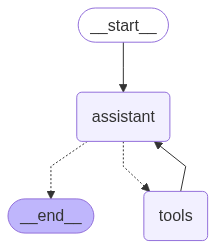

In [6]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [7]:
messages = [HumanMessage(content="Divide 6790 by 5")]

messages = react_graph.invoke({"messages": messages, "input_file": None})

In [10]:
messages['messages']

[HumanMessage(content='Divide 6790 by 5', additional_kwargs={}, response_metadata={}, id='485b9cb0-d2ea-429c-83fc-b9a2e4b1034b'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'divide', 'arguments': '{"a": 6790.0, "b": 5.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--377134a5-ba07-4175-98a0-508a18266a58-0', tool_calls=[{'name': 'divide', 'args': {'a': 6790.0, 'b': 5.0}, 'id': '66a1acd7-2902-4eaf-b5b9-4c6977c193b1', 'type': 'tool_call'}], usage_metadata={'input_tokens': 174, 'output_tokens': 5, 'total_tokens': 179, 'input_token_details': {'cache_read': 0}}),
 ToolMessage(content='1358.0', name='divide', id='79109014-8fde-4184-be97-fe781a5ee542', tool_call_id='66a1acd7-2902-4eaf-b5b9-4c6977c193b1'),
 AIMessage(content='6790 divided by 5 is 1358.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ra

In [14]:
react_graph.invoke({"messages": [HumanMessage(content="Divide 6790 by 5")], "input_file": None})

{'input_file': None,
 'messages': [HumanMessage(content='Divide 6790 by 5', additional_kwargs={}, response_metadata={}, id='7114f622-24e6-4372-bf35-35a12b28161f'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'divide', 'arguments': '{"a": 6790.0, "b": 5.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--14f4f811-248a-43b8-a067-dd4d75a7f467-0', tool_calls=[{'name': 'divide', 'args': {'a': 6790.0, 'b': 5.0}, 'id': '5cd2d340-2f5a-48e3-ba1c-a0079136a15a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 174, 'output_tokens': 5, 'total_tokens': 179, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='1358.0', name='divide', id='db6a5bab-3282-434b-b0d2-7e0dbd855b69', tool_call_id='5cd2d340-2f5a-48e3-ba1c-a0079136a15a'),
  AIMessage(content='6790 divided by 5 is 1358.', additional_kwargs={}, response_metadata={'prompt_feed

In [8]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide 6790 by 5
================================== Ai Message ==================================
Tool Calls:
  divide (66a1acd7-2902-4eaf-b5b9-4c6977c193b1)
 Call ID: 66a1acd7-2902-4eaf-b5b9-4c6977c193b1
  Args:
    a: 6790.0
    b: 5.0
================================= Tool Message =================================
Name: divide

1358.0
================================== Ai Message ==================================

6790 divided by 5 is 1358.


In [ ]:
final_message = messages['messages'][-1]
if isinstance(final_message, AIMessage):
    print(final_message.content)
else:
    print("The last message is not an AI message.")

## Training program
MR Wayne left a note with his training program for the week. I came up with a recipe for dinner left in a note.

you can find the document [HERE](https://huggingface.co/datasets/agents-course/course-images/blob/main/en/unit2/LangGraph/Batman_training_and_meals.png), so download it and upload it in the local folder.

![Training](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/unit2/LangGraph/Batman_training_and_meals.png)

In [14]:
messages = [HumanMessage(content="According the note provided by MR wayne in the provided images. What's the list of items I should buy for the dinner menu ?")]

messages = react_graph.invoke({"messages": messages, "input_file": "Batman_training_and_meals.png"})

In [15]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According the note provided by MR wayne in the provided images. What's the list of items I should buy for the dinner menu ?
================================== Ai Message ==================================
Tool Calls:
  extract_text (8def9bd8-c86b-451a-8e8a-51031134f915)
 Call ID: 8def9bd8-c86b-451a-8e8a-51031134f915
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

TRAINING SCHEDULE
For the week of 2/20-2/26
SUNDAY 2/20
MORNING
30 minute jog
30 minute meditation
EVENING
clean and jerk lifts - 3 reps/8 sets. 262 lbs.
5 sets metabolic conditioning:
1½ mile run
21 kettlebell swings
12 pull-ups
30 minutes flexibility
30 minutes sparring
MONDAY 2/21
30 minute jog
MORNING
EVENING
30 minutes traditional kata (focus on Japanese forms)
5 sets 20 foot rope climb
30 minutes gymnastic rings (work on muscle ups in
pa

In [16]:
messages = [HumanMessage(content="According the note provided by MR wayne in the provided images. What's the total number of unique strength exercise he does ?")]

messages = react_graph.invoke({"messages": messages, "input_file": "Batman_training_and_meals.png"})

In [17]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According the note provided by MR wayne in the provided images. What's the total number of unique strength exercise he does ?
================================== Ai Message ==================================
Tool Calls:
  extract_text (432d3662-b19c-4a1a-9d49-de6875982707)
 Call ID: 432d3662-b19c-4a1a-9d49-de6875982707
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

TRAINING SCHEDULE
For the week of 2/20-2/26
SUNDAY 2/20
MORNING
30 minute jog
30 minute meditation
EVENING
clean and jerk lifts - 3 reps/8 sets. 262 lbs.
5 sets metabolic conditioning:
1½ mile run
21 kettlebell swings
12 pull-ups
30 minutes flexibility
30 minutes sparring
MONDAY 2/21
30 minute jog
MORNING
EVENING
30 minutes traditional kata (focus on Japanese forms)
5 sets 20 foot rope climb
30 minutes gymnastic rings (work on muscle ups in


In [18]:
messages = [HumanMessage(content="According the note provided by MR wayne in the provided images. How much does MR Wayne weigh ? Explain yourself.")]

messages = react_graph.invoke({"messages": messages, "input_file": "Batman_training_and_meals.png"})

In [19]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According the note provided by MR wayne in the provided images. How much does MR Wayne weigh ? Explain yourself.
================================== Ai Message ==================================
Tool Calls:
  extract_text (2d0c256a-3516-4fad-914f-eeadf5aa5c6b)
 Call ID: 2d0c256a-3516-4fad-914f-eeadf5aa5c6b
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

TRAINING SCHEDULE
For the week of 2/20-2/26
SUNDAY 2/20
MORNING
30 minute jog
30 minute meditation
EVENING
clean and jerk lifts - 3 reps/8 sets. 262 lbs.
5 sets metabolic conditioning:
1½ mile run
21 kettlebell swings
12 pull-ups
30 minutes flexibility
30 minutes sparring
MONDAY 2/21
MORNING
30 minute jog
EVENING
30 minutes traditional kata (focus on Japanese forms)
5 sets 20 foot rope climb
30 minutes gymnastic rings (work on muscle ups in
particular)
h